# Artificial Bee Colony (ABC)

In [1]:
import os
import pandas as pd
import numpy as np
import time
import json
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Data
df = pd.read_csv('processed_cicids2017.csv')

# Drop missing values
df.dropna(inplace=True)

X = df.drop(columns=['Label'])
y = df['Label']
feature_names = X.columns.tolist()

# Train/Test Split
# Using stratified split and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total Features: {X.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")

Total Features: 77
Training Samples: 201663


In [3]:
class ABC_FeatureSelector:
    def __init__(self, X_train, y_train, colony_size=20, n_iterations=10, limit=3, n_jobs=4):
        self.X_train = X_train
        self.y_train = y_train
        self.colony_size = colony_size
        self.n_iterations = n_iterations
        self.limit = limit
        self.n_jobs = n_jobs
        
        # Split Valid for Fitness Evaluation
        self.X_sub, self.X_val, self.y_sub, self.y_val = train_test_split(
            self.X_train, self.y_train, test_size=0.2, random_state=42, stratify=self.y_train
        )
        
        # Calculations:
        self.n_employed = self.colony_size // 2
        self.n_onlookers = self.colony_size - self.n_employed
        self.n_features = self.X_train.shape[1]
        
        # Population Initialization
        self.foods = np.random.randint(0, 2, size=(self.n_employed, self.n_features))
        # Ensure no empty features
        for i in range(self.n_employed):
            if np.sum(self.foods[i]) == 0:
                self.foods[i][np.random.randint(0, self.n_features)] = 1
                
        self.fitness = np.zeros(self.n_employed)
        self.trials = np.zeros(self.n_employed)
        
        self.best_solution = None
        self.best_fitness = -1.0
        self.fitness_history = []
        self.pbar = None
        
        # Pareto History
        self.history = {'iteration': [], 'accuracy': [], 'features': [], 'fitness': []}
        self.training_time = 0

    def calculate_fitness(self, solution):
        selected_indices = np.where(solution == 1)[0]
        
        if len(selected_indices) == 0:
            return 0.0
            
        X_sub_sel = self.X_sub[:, selected_indices]
        X_val_sel = self.X_val[:, selected_indices]
        
        # Thread safety requires local classifier
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_sub_sel, self.y_sub)
        pred = clf.predict(X_val_sel)
        accuracy = accuracy_score(self.y_val, pred)
        
        # --- Enhanced Fitness: Accuracy + Low Correlation (Same as GA) ---
        if len(selected_indices) > 1:
            with np.errstate(invalid='ignore', divide='ignore'):
                corr_matrix = np.corrcoef(X_val_sel, rowvar=False)
                corr_matrix = np.nan_to_num(corr_matrix)
                abs_corr = np.abs(corr_matrix)
                mask = np.triu(np.ones_like(abs_corr, dtype=bool), k=1)
                avg_corr = np.mean(abs_corr[mask]) if np.any(mask) else 0
        else:
            avg_corr = 0
            
        # Composite Fitness
        fitness = (accuracy + (1 - avg_corr)) / 2
        
        return fitness

    def _evaluate_population(self, population):
        # Parallel evaluation of fitness using Threading
        results = Parallel(n_jobs=self.n_jobs, backend="threading")(
            delayed(self.calculate_fitness)(ind) for ind in population
        )
        return np.array(results)

    def neighbor_search(self, current_solution_idx):
        # Generate new candidate solution V_i near X_i
        candidate = self.foods[current_solution_idx].copy()
        
        # Select random neighbor k != i
        k = np.random.randint(0, self.n_employed)
        while k == current_solution_idx:
            k = np.random.randint(0, self.n_employed)
            
        # Select random dimension (feature) j to change
        j = np.random.randint(0, self.n_features)
        
        # Equation: v_ij = x_ij + phi * (x_ij - x_kj)
        # For binary, we toggle the bit if the continuous version would push it
        # Simple binary mutation: Just flip the bit
        candidate[j] = 1 - candidate[j]
        
        if np.sum(candidate) == 0:
            candidate[np.random.randint(0, self.n_features)] = 1
            
        return candidate

    def run(self):
        # Initial evaluation
        print(f"Initializing ABC with {self.colony_size} bees, {self.n_iterations} iterations, {self.n_jobs} threads...")
        start_time = time.time()
        
        self.fitness = self._evaluate_population(self.foods)
        
        # Update Global Best
        best_idx = np.argmax(self.fitness)
        if self.fitness[best_idx] > self.best_fitness:
            self.best_fitness = self.fitness[best_idx]
            self.best_solution = self.foods[best_idx].copy()
            
        self.pbar = tqdm(total=self.n_iterations, desc="ABC Optimization")
        
        for iteration in range(self.n_iterations):
            # --- PHASE 1: Employed Bees ---
            new_candidates = []
            for i in range(self.n_employed):
                neighbor = self.neighbor_search(i)
                new_candidates.append(neighbor)
            
            # Parallel Eval
            new_fitness_scores = self._evaluate_population(new_candidates)
            
            # Greedy Selection
            for i in range(self.n_employed):
                if new_fitness_scores[i] > self.fitness[i]:
                    self.foods[i] = new_candidates[i]
                    self.fitness[i] = new_fitness_scores[i]
                    self.trials[i] = 0
                else:
                    self.trials[i] += 1

            # --- PHASE 2: Onlooker Bees ---
            total_fitness = np.sum(self.fitness)
            probs = self.fitness / total_fitness if total_fitness > 0 else np.ones(self.n_employed) / self.n_employed
                
            onlooker_choices = []
            onlooker_indices = []
            
            chosen_indices = np.random.choice(self.n_employed, size=self.n_onlookers, p=probs)
            
            for idx in chosen_indices:
                neighbor = self.neighbor_search(idx)
                onlooker_choices.append(neighbor)
                onlooker_indices.append(idx)
            
            if len(onlooker_choices) > 0:
                onlooker_fitness = self._evaluate_population(onlooker_choices)
                
                for j, idx in enumerate(onlooker_indices):
                    if onlooker_fitness[j] > self.fitness[idx]:
                        self.foods[idx] = onlooker_choices[j]
                        self.fitness[idx] = onlooker_fitness[j]
                        self.trials[idx] = 0
                    else:
                        self.trials[idx] += 1
                        
            # --- PHASE 3: Scout Bees ---
            for i in range(self.n_employed):
                if self.trials[i] > self.limit:
                    random_sol = np.random.randint(0, 2, size=self.n_features)
                    if np.sum(random_sol) == 0: random_sol[np.random.randint(0, self.n_features)] = 1
                    
                    self.foods[i] = random_sol
                    # Re-eval single scout (fast)
                    self.fitness[i] = self.calculate_fitness(random_sol)
                    self.trials[i] = 0
                    
            # Update Global Best
            current_best_idx = np.argmax(self.fitness)
            if self.fitness[current_best_idx] > self.best_fitness:
                self.best_fitness = self.fitness[current_best_idx]
                self.best_solution = self.foods[current_best_idx].copy()
            
            # --- History Tracking for Pareto ---
            # Re-calculate Stats for the Best Solution of this Iteration
            best_sol_iter = self.foods[current_best_idx] # Or use Global Best? Use current best so far (Global)
            # Actually, Pareto usually tracks the evolution of the global best or the population.
            # Tracking the Global Best is safer.
            
            sel_ind = np.where(self.best_solution == 1)[0]
            if len(sel_ind) > 0:
                X_sub_sel = self.X_sub[:, sel_ind]
                X_val_sel = self.X_val[:, sel_ind]
                clf = DecisionTreeClassifier(random_state=42)
                clf.fit(X_sub_sel, self.y_sub)
                acc = clf.score(X_val_sel, self.y_val)
            else:
                acc = 0.0
            
            self.history['accuracy'].append(acc)
            self.history['features'].append(len(sel_ind))
            self.history['fitness'].append(self.best_fitness)
            self.history['iteration'].append(iteration + 1)
            
            self.fitness_history.append(self.best_fitness)
            self.pbar.update(1)
            self.pbar.set_description(f"ABC Best Fitness: {self.best_fitness:.4f} | Acc: {acc:.4f} | Feat: {len(sel_ind)}")
            
        end_time = time.time()
        self.training_time = end_time - start_time
        
        self.pbar.close()
        print(f"ABC execution complete. Time taken: {self.training_time:.2f} seconds.")
        
        return self.best_solution, self.best_fitness, self.fitness_history

    def get_runtime(self):
        return self.training_time

In [4]:
# Run ABC Feature Selection
# Use available CPU cores
n_jobs = os.cpu_count()
print(f"Using {n_jobs} CPU cores for processing.")

# limit=3 means if a solution doesn't improve for 3 cycles, it resets
abc_selector = ABC_FeatureSelector(X_train_scaled, y_train, colony_size=24, n_iterations=20, limit=3, n_jobs=n_jobs)

best_mask, best_score, history = abc_selector.run()

Using 12 CPU cores for processing.
Initializing ABC with 24 bees, 20 iterations, 12 threads...


ABC Optimization:   0%|          | 0/20 [00:00<?, ?it/s]

ABC execution complete. Time taken: 405.74 seconds.


Algorithm Finished.
Best Solution Fitness: 0.9676
Number of Selected Features: 30
Computational Cost (Runtime): 405.7440 seconds
Features: ['Destination Port', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Flow Bytes/s', 'Flow IAT Min', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Fwd PSH Flags', 'Fwd URG Flags', 'Bwd Header Length', 'Fwd Packets/s', 'Min Packet Length', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Packets/Bulk', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward', 'Active Std', 'Active Max', 'Idle Mean', 'Idle Std']


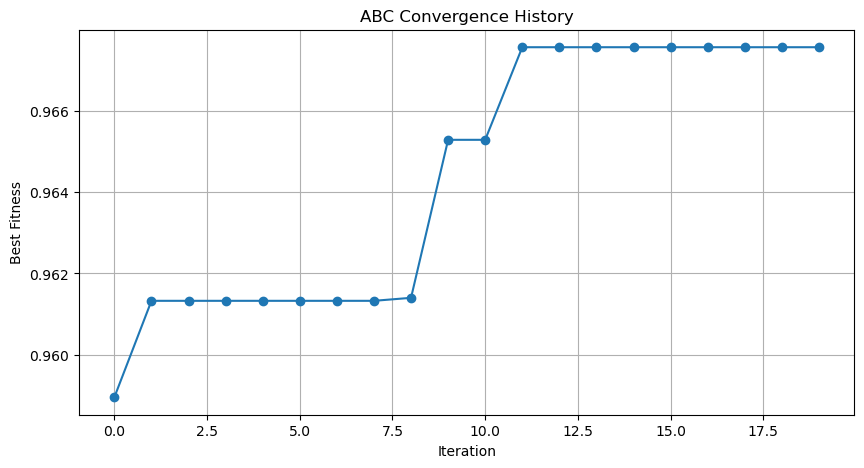

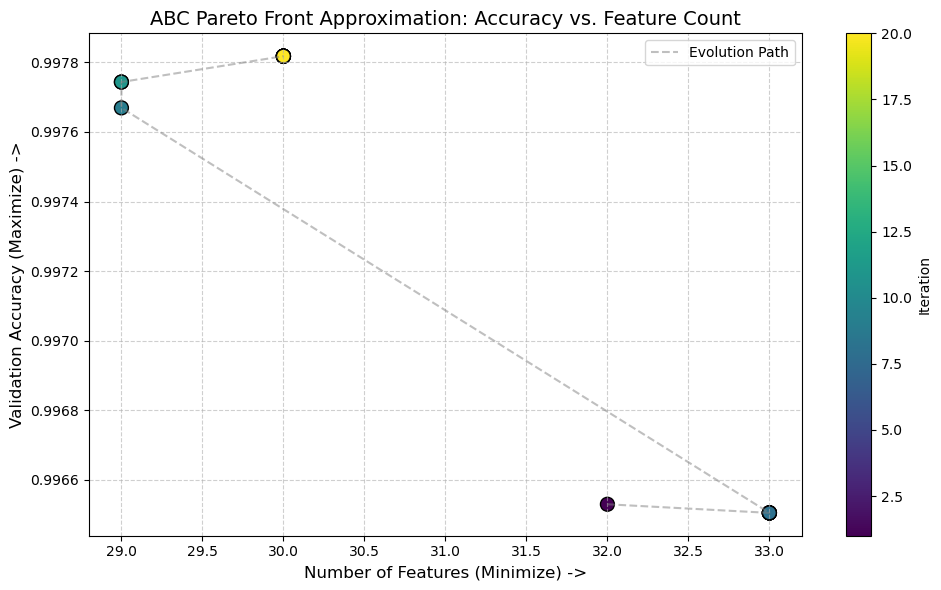

In [5]:
# Retrieve Results
selected_indices = np.where(best_mask == 1)[0]
selected_features = [feature_names[i] for i in selected_indices]
abc_runtime = abc_selector.get_runtime()

print(f"Algorithm Finished.")
print(f"Best Solution Fitness: {best_score:.4f}")
print(f"Number of Selected Features: {len(selected_features)}")
print(f"Computational Cost (Runtime): {abc_runtime:.4f} seconds")
print(f"Features: {selected_features}")

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(history, marker='o')
plt.title('ABC Convergence History')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.grid(True)
plt.show()

# --- Pareto Front Visualization ---
history_dict = abc_selector.history

plt.figure(figsize=(10, 6))
# Evolution Path
plt.plot(history_dict['features'], history_dict['accuracy'], color='gray', linestyle='--', alpha=0.5, label='Evolution Path')
# Points (Iterations)
plt.scatter(history_dict['features'], history_dict['accuracy'], c=history_dict['iteration'], cmap='viridis', s=100, edgecolors='black')

plt.colorbar(label='Iteration')
plt.title('ABC Pareto Front Approximation: Accuracy vs. Feature Count', fontsize=14)
plt.xlabel('Number of Features (Minimize) ->', fontsize=12)
plt.ylabel('Validation Accuracy (Maximize) ->', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Training Final Classifier on ABC Selected Features...

Classification Report (ABC Selected Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41901
           1       0.99      0.99      0.99      8515

    accuracy                           1.00     50416
   macro avg       1.00      1.00      1.00     50416
weighted avg       1.00      1.00      1.00     50416

=== ABC Final Metrics ===
Accuracy: 0.997580
Precision: 0.997579
Recall: 0.997580
F1-Score: 0.997580
Detection Rate (TPR): 0.992366
False Positive Rate (FPR): 0.001360
Feature Count: 30.000000
Runtime (s): 405.743999


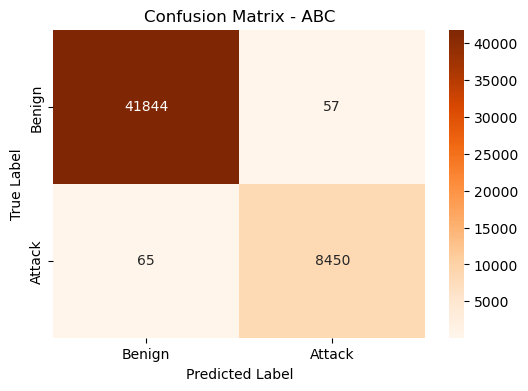

ABC metrics saved to results/abc_metrics.json

=== Model Comparison Results ===
                Baseline  ABC Selection
Accuracy        0.998155       0.997580
Precision       0.998156       0.997579
Recall          0.998155       0.997580
F1-Score        0.998155       0.997580
Feature Count  77.000000      30.000000


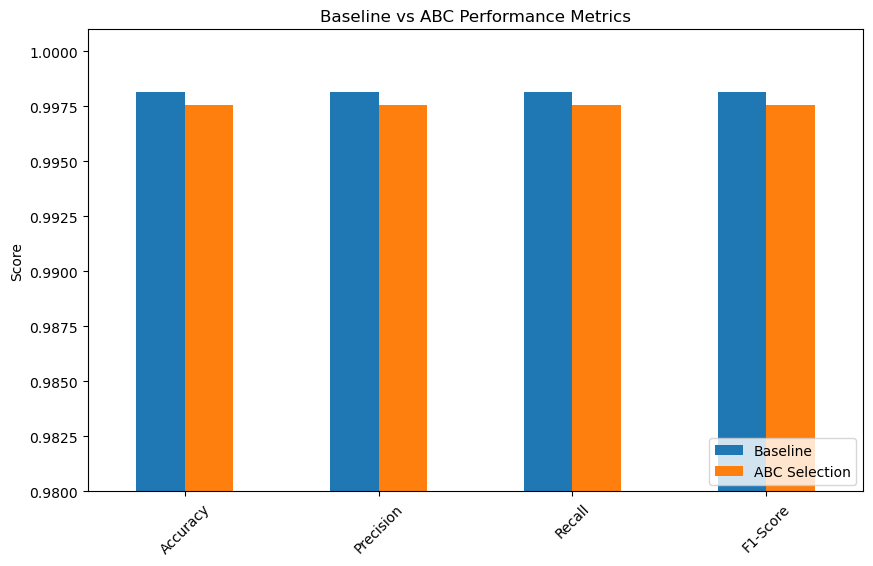


Feature Reduction: 77 -> 30
Reduction Percentage: 61.04%


In [ ]:
# Train Final Model with ABC Features
print("\nTraining Final Classifier on ABC Selected Features...")

X_train_abc = X_train_scaled[:, selected_indices]
X_test_abc = X_test_scaled[:, selected_indices]

final_model = DecisionTreeClassifier(random_state=42)
final_model.fit(X_train_abc, y_train)

y_pred_abc = final_model.predict(X_test_abc)

# Evaluation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_abc).ravel()

abc_acc = accuracy_score(y_test, y_pred_abc)
abc_prec = precision_score(y_test, y_pred_abc, average='weighted')
abc_rec = recall_score(y_test, y_pred_abc, average='weighted')
abc_f1 = f1_score(y_test, y_pred_abc, average='weighted')

detection_rate_abc = tp / (tp + fn)
false_positive_rate_abc = fp / (fp + tn)

print("\nClassification Report (ABC Selected Features):")
print(classification_report(y_test, y_pred_abc))

abc_final_metrics = {
    'Accuracy': abc_acc,
    'Precision': abc_prec,
    'Recall': abc_rec,
    'F1-Score': abc_f1,
    'Detection Rate (TPR)': detection_rate_abc,
    'False Positive Rate (FPR)': false_positive_rate_abc,
    'Feature Count': len(selected_features),
    'Runtime (s)': abc_runtime
}

print("=== ABC Final Metrics ===")
for k, v in abc_final_metrics.items():
    print(f"{k}: {v:.6f}")

conf_matrix_abc = confusion_matrix(y_test, y_pred_abc)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_abc, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix - ABC')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- Comparison with Others ---
# 1. Load Baseline Metrics from JSON
try:
    with open('results/baseline_metrics.json', 'r') as f:
        baseline_metrics = json.load(f)
except FileNotFoundError:
    print("Warning: baseline_metrics.json not found. Using default placeholder values.")
    baseline_metrics = {
        'Accuracy': 0.9982,
        'Precision': 0.9982,
        'Recall': 0.9982,
        'F1-Score': 0.9982,
        'Feature Count': 77
    }

abc_metrics = {
    'Method': 'Artificial Bee Colony (ABC)',
    'Accuracy': abc_acc,
    'Precision': abc_prec,
    'Recall': abc_rec,
    'F1-Score': abc_f1,
    'Detection Rate (TPR)': detection_rate_abc,
    'False Positive Rate (FPR)': false_positive_rate_abc,
    'Feature Count': len(selected_features),
    'Runtime (s)': abc_runtime
}

# --- SAVE ABC METRICS to JSON ---
abc_metrics_path = 'results/abc_metrics.json'
with open(abc_metrics_path, 'w') as f:
    json.dump(abc_metrics, f, indent=4)
print(f"ABC metrics saved to {abc_metrics_path}")

# Comparison Table
metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Feature Count']
baseline_filtered = {k: baseline_metrics.get(k, 0) for k in metrics_keys}
abc_filtered = {k: abc_metrics.get(k, 0) for k in metrics_keys}

results_df = pd.DataFrame([baseline_filtered, abc_filtered], index=['Baseline', 'ABC Selection'])
print("\n=== Model Comparison Results ===")
print(results_df.T)

# Visualization
results_without_count = results_df.drop('Feature Count', axis=1)
results_without_count.T.plot(kind='bar', figsize=(10, 6))
plt.title('Baseline vs ABC Performance Metrics')
plt.ylabel('Score')
plt.ylim(0.98, 1.001) 
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

print(f"\nFeature Reduction: {baseline_metrics['Feature Count']} -> {abc_metrics['Feature Count']}")
print(f"Reduction Percentage: {((baseline_metrics['Feature Count'] - abc_metrics['Feature Count'])/baseline_metrics['Feature Count'])*100:.2f}%")